Decision Tree 는 KNN 처럼 거리기반 X

조건 분기 기반 모델 => 표준화 영향 거의 X

---

# Decision Tree

데이터를 여러 조건으로 나누면서 분류하는 모델

```text
worst radius <= 16.8 ?
├── True  → benign
└── False → malignant
```

내부적으로 여러 개의 if-else 조건문을 만든다고 보면 됨

---

# 1. 데이터 준비

In [1]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

cancer = load_breast_cancer()

X = cancer.data
y = cancer.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    random_state=42,
    test_size=0.2,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("클래스 이름:", cancer.target_names)

X_train shape: (455, 30)
X_test shape: (114, 30)
클래스 이름: ['malignant' 'benign']


---

# 2. 기본 Decision Tree 학습

우선, 깊이 제한 없이 학습

In [3]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=42)

model.fit(X_train, y_train)

train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)

print("Train 정확도:", train_score)
print("Test 정확도:", test_score)

Train 정확도: 1.0
Test 정확도: 0.9122807017543859


여기서 train정확도는 1.0 인데, test정확도는 그보다 낮다.

특히 train정확도가 1.0 이 나왔다는 것은, 모델이 학습 데이터를 거의 외운 상태라고 볼 수 있다.

**Decision Tree 는 제한 없이 키우면 과적합되기 쉽다.**

---

# 3. 트리 구조 확인하기

### 3-1. 텍스트로 트리 보기

In [8]:
from sklearn.tree import export_text

tree_text = export_text(
    model,
    feature_names=list(cancer.feature_names)
)

print(tree_text)

|--- worst radius <= 16.80
|   |--- worst concave points <= 0.14
|   |   |--- area error <= 91.56
|   |   |   |--- area error <= 38.60
|   |   |   |   |--- smoothness error <= 0.00
|   |   |   |   |   |--- worst texture <= 26.64
|   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |--- worst texture >  26.64
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |--- smoothness error >  0.00
|   |   |   |   |   |--- worst texture <= 33.27
|   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |--- worst texture >  33.27
|   |   |   |   |   |   |--- worst texture <= 33.80
|   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |--- worst texture >  33.80
|   |   |   |   |   |   |   |--- class: 1
|   |   |   |--- area error >  38.60
|   |   |   |   |--- texture error <= 2.01
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- texture error >  2.01
|   |   |   |   |   |--- concave points error <= 0.01
|   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |--- conca

위의 텍스트 tree는 모델이 실제로 어떤 조건으로 데이터를 나눴는지 보여준다.

---

### 3-2. 그림으로 트리 보기

전체 트리는 너무 커질 수 있으니까 max_depth=3 정도로 제한해서 시각화하면

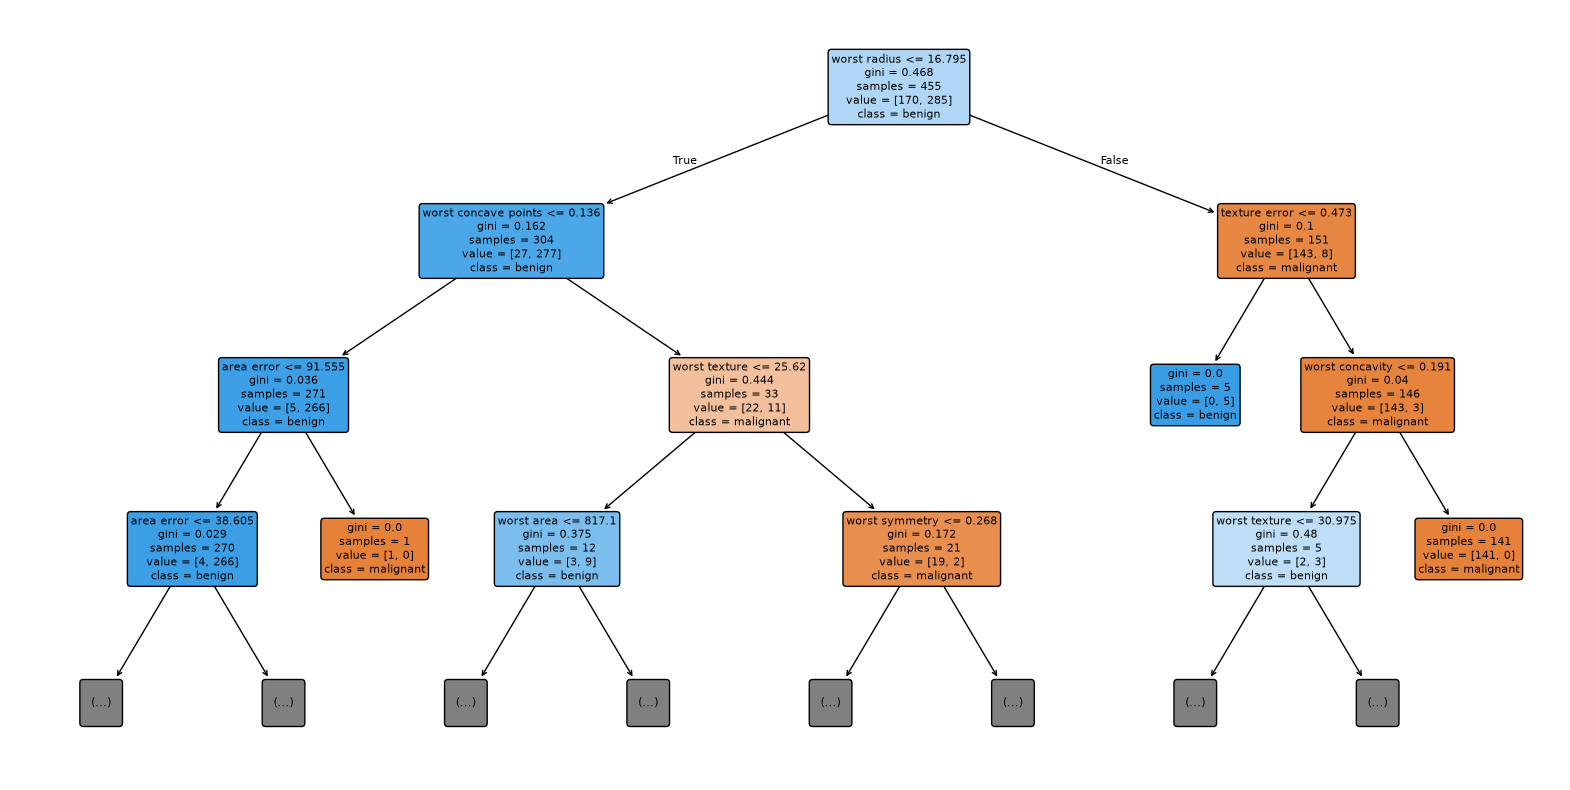

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))

plot_tree(
    model,
    feature_names=cancer.feature_names, # 사람이 보기 쉽게 인덱스번호 대신 feature 이름 표시
    class_names=cancer.target_names,    # 트리 각 노드의 예측 class가 트리 그림에서 숫자가 아니라 이름으로 표시
    filled=True,    # 각 노드에 색을 채워서 표현
    rounded=True,   # 트리 노드 박스의 모서리 둥글게
    max_depth=3     # 표시할 트리의 깊이 최대 3개까지만 보여줌
)

plt.show()

- feature 조건 = 데이터를 나누는 기준
- gini = 불순도, 낮을수록 한 클래스가 잘 모임
- samples = 해당 노드에 들어온 데이터 개수
- values = 클래스별 데이터 개수
- class = 해당 노드의 예측 클래스

---

# 4. max_depth 제한 실험

max_depth 는 트리의 최대 깊이이다.

- max_depth 작음 -> 단순한 트리 -> 과소적합 가능
- max_depth 큼 -> 복잡한 트리 -> 과적합 가능

#### max_depth 바꿔가며 Train/Test 정확도 비교

In [10]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier

results = []

for depth in range(1, 11):
    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    model.fit(X_train, y_train)

    train_score = model.score(X_train, y_train)
    test_score = model.score(X_test, y_test)

    results.append({
        "max_depth": depth,
        "Train_accuracy": train_score,
        "Test_accuracy": test_score
    })

result_df = pd.DataFrame(results)
result_df

,max_depth,Train_accuracy,Test_accuracy
0,1,0.923077,0.921053
1,2,0.958242,0.894737
2,3,0.975824,0.938596
3,4,0.986813,0.938596
4,5,0.993407,0.921053
5,6,0.997802,0.912281
6,7,1.000000,0.912281
7,8,1.000000,0.912281
8,9,1.000000,0.912281
9,10,1.000000,0.912281


---

# 5. Test 정확도 높은 순서로 보기



In [ ]:
result_df.sort_values("Test_accuracy", ascending=False) 
# Test_accuracy 내림차순

,max_depth,Train_accuracy,Test_accuracy
3,4,0.986813,0.938596
2,3,0.975824,0.938596
4,5,0.993407,0.921053
0,1,0.923077,0.921053
6,7,1.000000,0.912281
5,6,0.997802,0.912281
8,9,1.000000,0.912281
7,8,1.000000,0.912281
9,10,1.000000,0.912281
1,2,0.958242,0.894737


# 6. 그래프로 확인

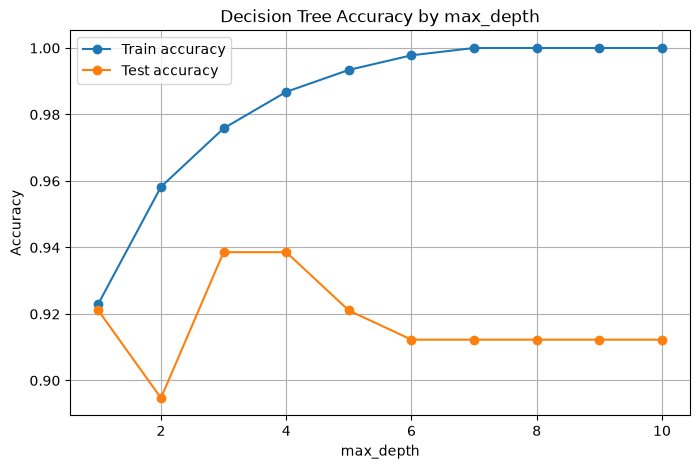

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(result_df["max_depth"], result_df["Train_accuracy"], marker="o", label="Train accuracy")
plt.plot(result_df["max_depth"], result_df["Test_accuracy"], marker="o", label="Test accuracy")

plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree Accuracy by max_depth")
plt.legend()
plt.grid(True)
plt.show()

### 위 그래프에서 봐야 할 것
1. max_depth 가 커질수록 Train 정확도가 올라가는가?
2. Test 정확도는 어느 지점에서 가장 높은가?
3. Train과 Test 차이가 너무 커지는 지점이 있는가?

위의 그래프를 봤을 때, 
**max_depth=3 또는 4가 가장 적절하고, 5 이상부터는 과적합 경향이 강하다**

max_depth=4 일때가 훈련 데이터의 accuracy가 더 높지만, 이정도의 차이면 보통은 더 단순한 모델인 max_depth=3 을 선택하는 게 낫다.

---

# 7. Feature Importance 확인

Decision Tree는 어떤 feature를 중요하게 봤는지도 확인할 수 있다.

In [15]:
import pandas as pd

importance_df = pd.DataFrame({
    "feature": cancer.feature_names,
    "importance": model.feature_importances_
})

importance_df = importance_df.sort_values("importance", ascending=False)

importance_df.head(10)

,feature,importance
20,worst radius,0.697811
27,worst concave points,0.116083
21,worst texture,0.058881
11,texture error,0.052661
26,worst concavity,0.016325
23,worst area,0.012678
13,area error,0.012085
28,worst symmetry,0.010733
24,worst smoothness,0.008452
17,concave points error,0.006261


여기서 importance 가 큰 feature 일수록 모델이 분류할 때 많이 사용한 특성이다.

그래프로 보고 싶으면

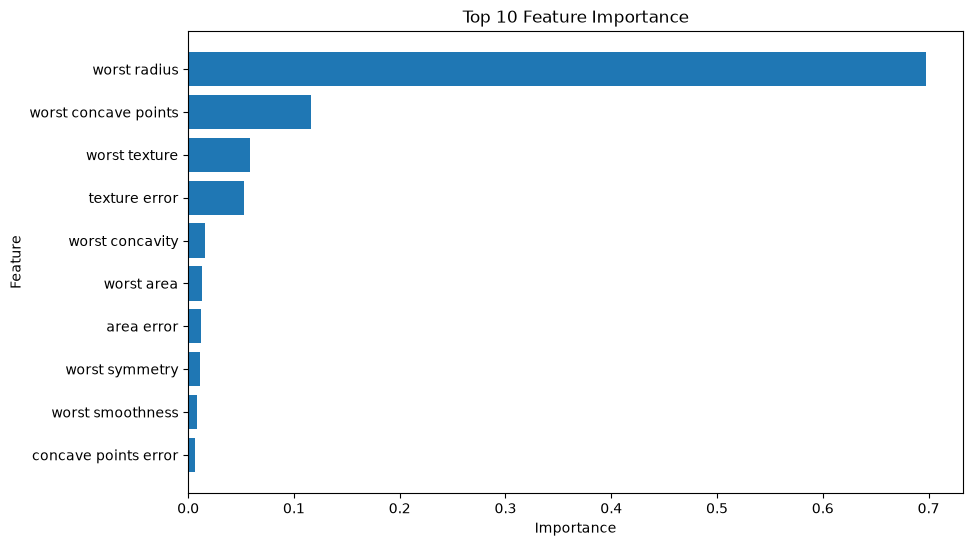

In [16]:
plt.figure(figsize=(10,6))

top10 = importance_df.head(10)

plt.barh(top10["feature"], top10["importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importance")
plt.gca().invert_yaxis()
plt.show()

---

# 8. 전체 코드

,max_depth,Train_accuracy,Test_accuracy
0,1,0.923077,0.921053
1,2,0.958242,0.894737
2,3,0.975824,0.938596
3,4,0.986813,0.938596
4,5,0.993407,0.921053
5,6,0.997802,0.912281
6,7,1.000000,0.912281
7,8,1.000000,0.912281
8,9,1.000000,0.912281
9,10,1.000000,0.912281


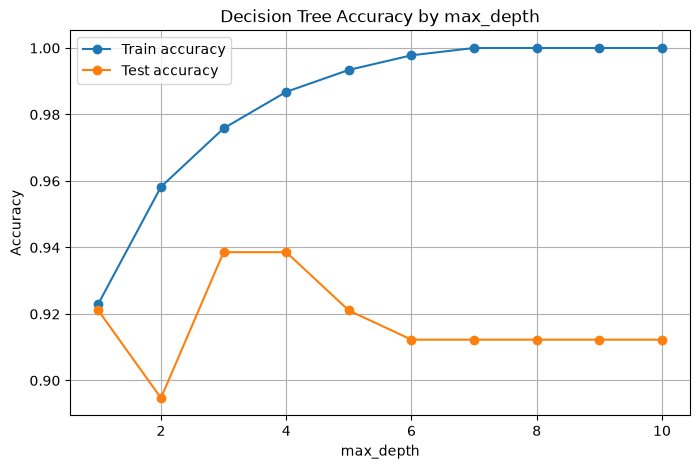

,max_depth,Train_accuracy,Test_accuracy
3,4,0.986813,0.938596


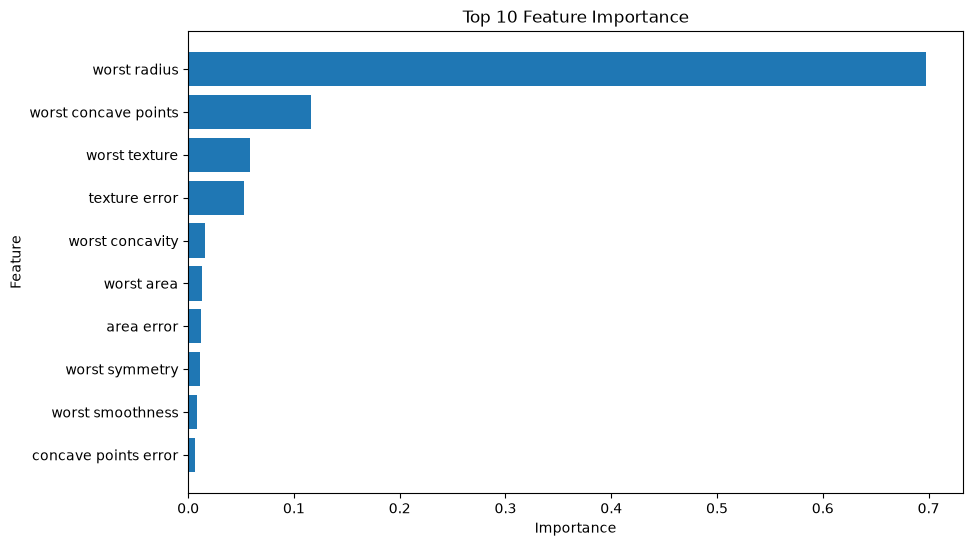

In [18]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
import pandas as pd
import matplotlib.pyplot as plt

# 1. 데이터 불러오기
cancer = load_breast_cancer()
X = cancer.data
y = cancer.target

# 2. train/test 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 3. max_depth 변화 실험
results = []

for depth in range(1, 11):
    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    model.fit(X_train, y_train)

    train_score = model.score(X_train, y_train)
    test_score = model.score(X_test, y_test)

    results.append({
        "max_depth": depth,
        "Train_accuracy": train_score,
        "Test_accuracy": test_score
    })

result_df = pd.DataFrame(results)

display(result_df)

# 4. 그래프
plt.figure(figsize=(8, 5))

plt.plot(result_df["max_depth"], result_df["Train_accuracy"], marker="o", label="Train accuracy")
plt.plot(result_df["max_depth"], result_df["Test_accuracy"], marker="o", label="Test accuracy")

plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree Accuracy by max_depth")
plt.legend()
plt.grid(True)
plt.show()

# 5. 가장 좋은 max_depth 확인
best_result = result_df.sort_values("Test_accuracy", ascending=False).head(1)
display(best_result)

plt.figure(figsize=(10,6))

top10 = importance_df.head(10)

plt.barh(top10["feature"], top10["importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importance")
plt.gca().invert_yaxis()
plt.show()

---

# 9. 정리

1. Decision Tree는 if-else 조건문처럼 데이터를 나누는 모델이다
2. Tree 깊이가 깊어질수록 학습 데이터는 더 잘 맞춘다.
3. 하지만 너무 깊으면 학습 데이터를 외워서 과적합될 수 있다.
4. max_depth는 트리 복잡도를 조절하는 핵심 하이퍼파라미터다.
5. Decision Tree는 거리 기반 모델이 아니므로 표준화가 필수는 아니다.
6. feature_importances_ 를 통해 어떤 특성이 중요했는지 확인할 수 있다.